In [1]:
from pathlib import Path
import json
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_FILE = Path("nfhs_full5-30.csv")
GEO_FILE = Path("data/india_states.geojson")
META_FILE = Path("data/meta.json")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Publication defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df_nfhs = pd.read_csv(DATA_FILE)
with open(META_FILE) as f:
    meta = json.load(f)

ROUND_YEARS = meta["round_years"]
WAVE_MAP = {"NFHS-3": 3, "NFHS-4": 4, "NFHS-5": 5, "NFHS-6": 6}
YEAR_MID = {"NFHS-3": 2005.5, "NFHS-4": 2015.5, "NFHS-5": 2020.0, "NFHS-6": 2023.5}

df_nfhs.head()

,state,round,year,area,section,indicator,harmonized_indicator,value,data_flag,source
0,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 5 years (%),NaN,6.6,NaN,NFHS-6 PDF
1,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 5 years (%),NaN,8.6,NaN,NFHS-6 PDF
2,India,NFHS-6,2023-24,Total,Population and Household Profile,Population below age 5 years (%),NaN,8.0,NaN,NFHS-6 PDF
3,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),22.0,NaN,NFHS-6 PDF
4,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),27.0,NaN,NFHS-6 PDF


In [2]:
# Keywords
FERTILITY_KW   = ["fertility rate", "tfr", "total fertility",
                        "birth rate", "children born", "births per"]
PHONE_KW       = ["mobile phone", "mobile telephone", "cell phone",
                        "smartphone", "phone ownership", "use mobile"]
INTERNET_KW    = ["internet", "online"]
EDUCATION_KW   = ["literate", "literacy", "education", "schooling",
                        "no education", "secondary", "years of school"]
WEALTH_KW      = ["wealth", "poorest", "richest", "quintile",
                        "household assets", "below poverty"]
URBAN_KW       = ["urban", "rural"]
CONTRACEPTION_KW     = ["contracepti", "family planning", "modern method",
                        "unmet need", "steriliz"]
EMPOWERMENT_KW       = ["decision", "autonomy", "empowerment",
                        "own money", "bank account", "financial"]

# Harmonised indicator crosswalk (Pakhare & Joshi)
HARMONISED = {
    "tfr": "Total fertility rate (children per woman)",
    "mobile": "Women with own mobile phone (%)",
    "internet": "Women who ever used the internet (%)",
    "literacy": "Women (15-49) who are literate (%)",
    "schooling": "Women (15-49) with 10+ years schooling (%)",
    "fp_modern": "FP: Any modern method (%)",
    "unmet_fp": "Total unmet need for FP (%)",
    "empowerment": "Married women participate in HH decisions (%)",
    "electricity": "Households with electricity (%)",
    "bank": "Women with own bank/savings account (%)",
}

MAIN_ROUNDS = ["NFHS-4", "NFHS-5", "NFHS-6"]
INTERNET_ROUNDS = ["NFHS-5", "NFHS-6"]
REG_CONTROLS = ["schooling", "fp_modern", "electricity"]  # literacy absent in NFHS-6

EXCLUDE_STATES = {"India"}
# Legacy UTs split in NFHS-3/4; merged from NFHS-5 onward
LEGACY_UTS = {"Dadra and Nagar Haveli", "Daman and Diu"}

In [3]:


def build_panel(df, rounds, indicators=None, area="Total", require_vars=None):
    """Wide state × round panel from harmonised indicators."""
    indicators = indicators or HARMONISED
    inv = {v: k for k, v in indicators.items()}
    require_vars = require_vars or ["tfr", "mobile"]

    sub = df[
        (df["area"] == area)
        & (~df["state"].isin(EXCLUDE_STATES))
        & (df["round"].isin(rounds))
        & (df["harmonized_indicator"].isin(indicators.values()))
    ].copy()
    sub = sub[~sub["data_flag"].astype(str).str.contains("Parenthesised", na=False)]

    wide = (
        sub.pivot_table(
            index=["state", "round"],
            columns="harmonized_indicator",
            values="value",
            aggfunc="first",
        )
        .rename(columns=inv)
        .reset_index()
    )
    wide["wave"] = wide["round"].map(WAVE_MAP)
    wide["year_mid"] = wide["round"].map(YEAR_MID)
    wide["year_label"] = wide["round"].map(ROUND_YEARS)

    req_cols = require_vars
    complete = wide.dropna(subset=req_cols)
    return wide, complete


panel_all, panel_main = build_panel(
    df_nfhs, MAIN_ROUNDS, require_vars=["tfr", "mobile"]
)
panel_reg = panel_main.dropna(subset=["tfr", "mobile"] + REG_CONTROLS)

panel_main.to_csv(OUTPUT_DIR / "panel_state_total.csv", index=False)
print(f"Main panel: {len(panel_main)} obs, {panel_main['state'].nunique()} states")
print(f"Regression sample: {len(panel_reg)} obs, {panel_reg['state'].nunique()} states")
panel_main.head()

Main panel: 107 obs, 38 states
Regression sample: 107 obs, 38 states


harmonized_indicator,state,round,fp_modern,electricity,empowerment,tfr,unmet_fp,literacy,schooling,internet,bank,mobile,wave,year_mid,year_label
0,Andaman and Nicobar Islands,NFHS-4,48.30,97.00,92.60,1.50,15.50,84.10,49.10,NaN,81.80,66.90,4,2015.5,2015-16
1,Andaman and Nicobar Islands,NFHS-5,57.73,97.58,94.48,1.28,13.51,85.97,52.47,34.79,89.21,80.83,5,2020.0,2019-21
2,Andaman and Nicobar Islands,NFHS-6,66.30,97.50,94.80,0.90,4.60,NaN,65.00,72.00,93.30,86.70,6,2023.5,2023-24
3,Andhra Pradesh,NFHS-4,69.40,98.80,79.90,1.80,4.70,62.90,34.30,NaN,66.30,36.20,4,2015.5,2015-16
4,Andhra Pradesh,NFHS-5,70.84,99.45,84.05,1.68,4.68,68.64,39.63,20.97,81.78,48.94,5,2020.0,2019-21


In [4]:
# --- Indicator audit: coverage matrix & keyword search ---

def coverage_matrix(df, var, rounds):
    tmp = df[df["round"].isin(rounds)].copy()
    tmp["has_val"] = tmp[var].notna().astype(int)
    return tmp.pivot_table(index="state", columns="round", values="has_val", aggfunc="max", fill_value=0)


print("=" * 60)
print("COVERAGE: TFR and Mobile (Total area, excl. India)")
print("=" * 60)
for label, var in [("TFR", "tfr"), ("Mobile", "mobile")]:
    mat = coverage_matrix(panel_all, var, MAIN_ROUNDS)
    print(f"\n{label} — states with data by round:")
    print(mat.sum(axis=0))
    missing = mat[(mat.sum(axis=1) < len(MAIN_ROUNDS))].index.tolist()
    if missing:
        print(f"  Incomplete states ({len(missing)}): {missing}")

lit_cov = coverage_matrix(panel_all, "literacy", MAIN_ROUNDS)
print(f"\nLiteracy NFHS-6 coverage: {lit_cov['NFHS-6'].sum()} states (0 expected — not harmonised in NFHS-6)")

print("\n" + "=" * 60)
print("ATTRITION")
print("=" * 60)
for desc, n in [
    ("All state-rounds (NFHS-4/5/6)", len(panel_all)),
    ("Non-missing TFR + mobile", len(panel_main)),
    ("+ non-missing controls", len(panel_reg)),
]:
    print(f"  {desc}: {n}")

def kw_match(text, keywords):
    t = str(text).lower()
    return any(k in t for k in keywords)

unmapped_phone = df_nfhs[
    (df_nfhs["area"] == "Total")
    & (~df_nfhs["state"].isin(EXCLUDE_STATES))
    & (df_nfhs["round"].isin(MAIN_ROUNDS))
    & (df_nfhs["harmonized_indicator"].isna() | (df_nfhs["harmonized_indicator"] == ""))
    & df_nfhs["indicator"].apply(lambda x: kw_match(x, PHONE_KW))
]["indicator"].unique()

print("\nUnmapped raw indicators matching PHONE_KW:")
print(unmapped_phone if len(unmapped_phone) else "  None — all phone measures are harmonised.")

COVERAGE: TFR and Mobile (Total area, excl. India)

TFR — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Mobile — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Literacy NFHS-6 coverage: 0 states (0 expected — not harmonised in NFHS-6)

ATTRITION
  All state-rounds (NFHS-4/5/6): 107
  Non-missing TFR + mobile: 107
  + non-missing controls: 107

Unmapped raw indicators matching PHONE_KW:
  None — all phone measures are harmonised.


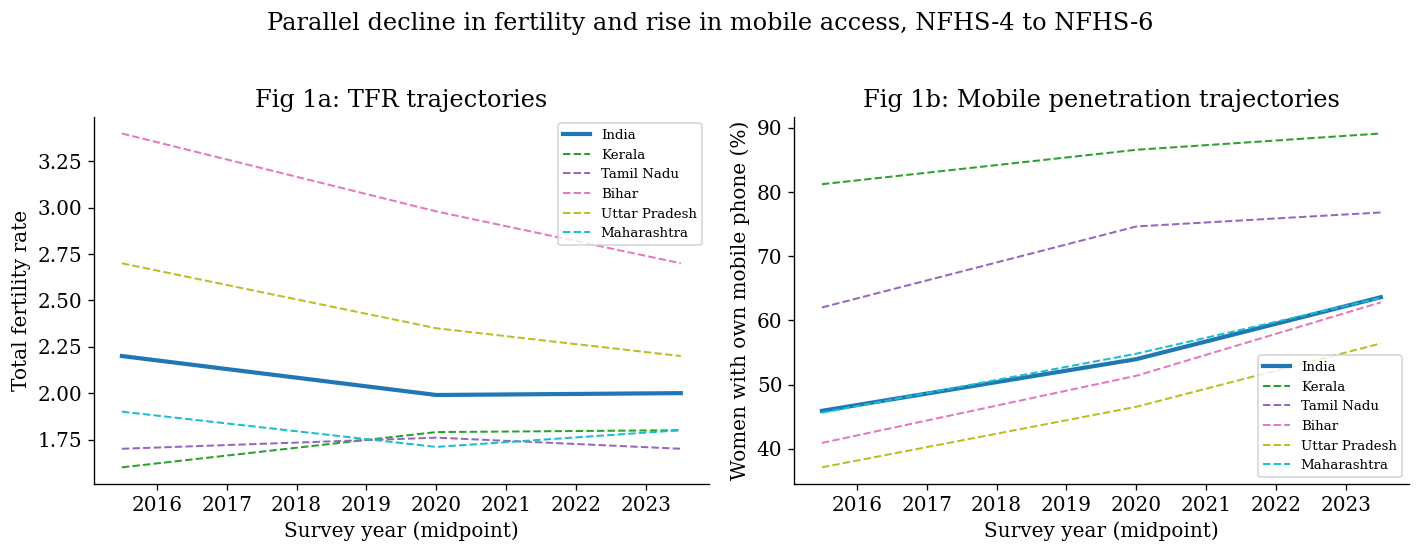

In [5]:
# --- Fig 1: Parallel trajectories — TFR vs mobile (India + selected states) ---

HIGHLIGHT_STATES = [
    "India", "Kerala", "Tamil Nadu", "Bihar", "Uttar Pradesh", "Maharashtra",
]

traj = df_nfhs[
    (df_nfhs["area"] == "Total")
    & (df_nfhs["state"].isin(HIGHLIGHT_STATES))
    & (df_nfhs["round"].isin(MAIN_ROUNDS))
    & (df_nfhs["harmonized_indicator"].isin([HARMONISED["tfr"], HARMONISED["mobile"]]))
].copy()
traj["year_mid"] = traj["round"].map(YEAR_MID)
traj = traj.pivot_table(
    index=["state", "round", "year_mid"], columns="harmonized_indicator", values="value"
).reset_index()
traj = traj.rename(columns={HARMONISED["tfr"]: "TFR", HARMONISED["mobile"]: "Mobile (%)"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(HIGHLIGHT_STATES)))

for i, state in enumerate(HIGHLIGHT_STATES):
    s = traj[traj["state"] == state].sort_values("year_mid")
    if s.empty:
        continue
    lw = 2.5 if state == "India" else 1.2
    ls = "-" if state == "India" else "--"
    axes[0].plot(s["year_mid"], s["TFR"], color=colors[i], lw=lw, ls=ls, label=state)
    axes[1].plot(s["year_mid"], s["Mobile (%)"], color=colors[i], lw=lw, ls=ls, label=state)

axes[0].set_ylabel("Total fertility rate")
axes[0].set_xlabel("Survey year (midpoint)")
axes[0].set_title("Fig 1a: TFR trajectories")
axes[1].set_ylabel("Women with own mobile phone (%)")
axes[1].set_xlabel("Survey year (midpoint)")
axes[1].set_title("Fig 1b: Mobile penetration trajectories")
for ax in axes:
    ax.legend(fontsize=8, loc="best")
fig.suptitle("Parallel decline in fertility and rise in mobile access, NFHS-4 to NFHS-6", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_trajectories.png", bbox_inches="tight")
plt.show()

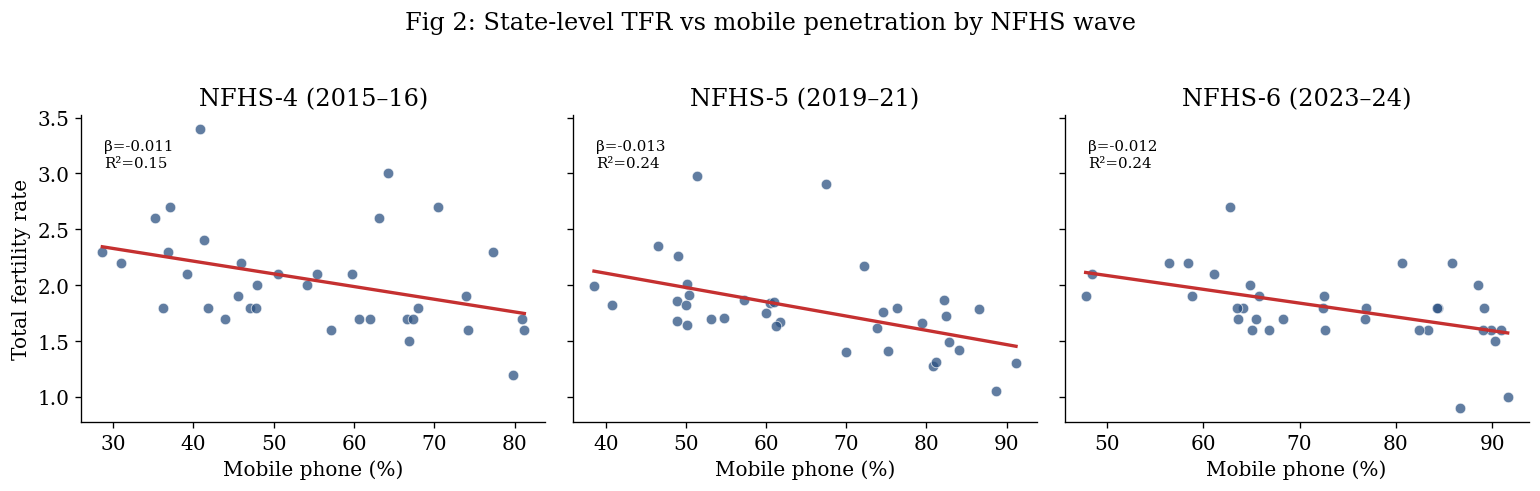

In [6]:
# --- Fig 2: Cross-sectional scatter — TFR vs mobile by wave ---

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
round_labels = {"NFHS-4": "2015–16", "NFHS-5": "2019–21", "NFHS-6": "2023–24"}

for ax, rnd in zip(axes, MAIN_ROUNDS):
    sub = panel_main[panel_main["round"] == rnd]
    ax.scatter(sub["mobile"], sub["tfr"], alpha=0.75, s=40, color="#2c5282", edgecolors="white", lw=0.5)
    if len(sub) >= 5:
        m = smf.ols("tfr ~ mobile", data=sub).fit()
        xline = np.linspace(sub["mobile"].min(), sub["mobile"].max(), 50)
        ax.plot(xline, m.params["Intercept"] + m.params["mobile"] * xline, color="#c53030", lw=2)
        ax.text(0.05, 0.92, f"β={m.params['mobile']:.3f}\nR²={m.rsquared:.2f}",
                transform=ax.transAxes, fontsize=9, va="top")
    ax.set_xlabel("Mobile phone (%)")
    ax.set_title(f"{rnd} ({round_labels[rnd]})")

axes[0].set_ylabel("Total fertility rate")
fig.suptitle("Fig 2: State-level TFR vs mobile penetration by NFHS wave", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig2_scatter_by_wave.png", bbox_inches="tight")
plt.show()

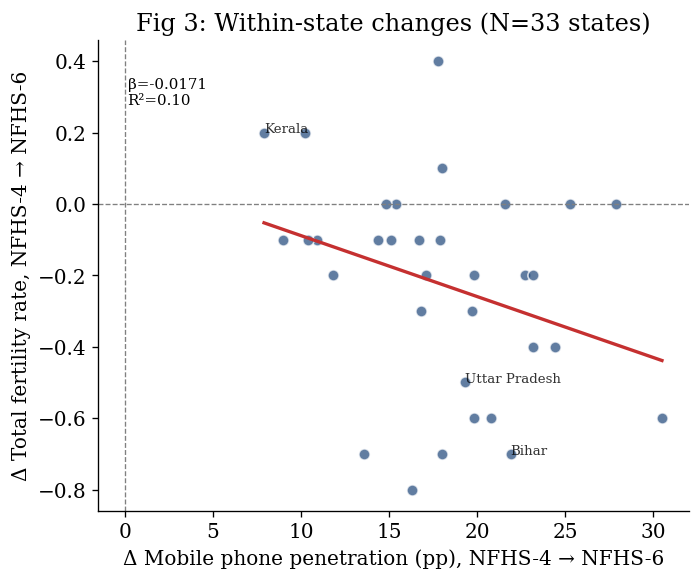

In [7]:
# --- Fig 3: Change-on-change (NFHS-4 → NFHS-6) ---

def wave_slice(df, rnd):
    return df[df["round"] == rnd].set_index("state")[["tfr", "mobile"]]

w4 = wave_slice(panel_main, "NFHS-4")
w6 = wave_slice(panel_main, "NFHS-6")
common = w4.index.intersection(w6.index)
delta = (w6.loc[common] - w4.loc[common]).rename(columns={"tfr": "d_tfr", "mobile": "d_mobile"})

fig, ax = plt.subplots(figsize=(6, 5))
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.scatter(delta["d_mobile"], delta["d_tfr"], alpha=0.75, s=45, color="#2c5282", edgecolors="white")

if len(delta) >= 5:
    m = smf.ols("d_tfr ~ d_mobile", data=delta.reset_index()).fit()
    xline = np.linspace(delta["d_mobile"].min(), delta["d_mobile"].max(), 50)
    ax.plot(xline, m.params["Intercept"] + m.params["d_mobile"] * xline, color="#c53030", lw=2)
    ax.text(0.05, 0.92, f"β={m.params['d_mobile']:.4f}\nR²={m.rsquared:.2f}",
            transform=ax.transAxes, fontsize=9, va="top")

for st in ["Kerala", "Bihar", "Uttar Pradesh"]:
    if st in delta.index:
        ax.annotate(st, (delta.loc[st, "d_mobile"], delta.loc[st, "d_tfr"]), fontsize=8, alpha=0.8)

ax.set_xlabel("Δ Mobile phone penetration (pp), NFHS-4 → NFHS-6")
ax.set_ylabel("Δ Total fertility rate, NFHS-4 → NFHS-6")
ax.set_title(f"Fig 3: Within-state changes (N={len(delta)} states)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig3_change_on_change.png", bbox_inches="tight")
plt.show()

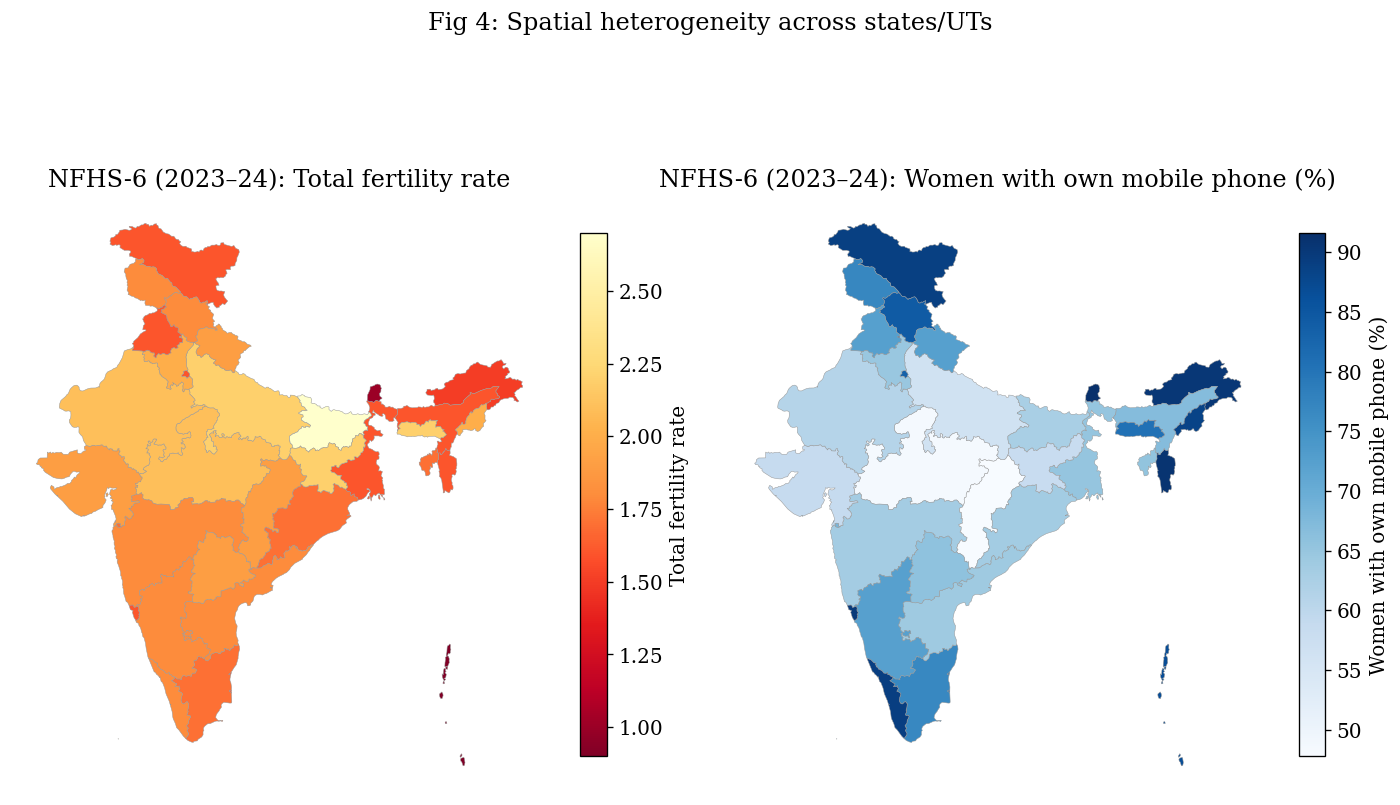

In [8]:
# --- Fig 4: Choropleth maps — NFHS-6 TFR and mobile ---

STATE_GEO_MAP = {
    "Dadra and Nagar Haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "Daman and Diu": "Dadra & Nagar Haveli and Daman & Diu",
}

nfhs6 = panel_main[panel_main["round"] == "NFHS-6"].copy()
nfhs6["geo_state"] = nfhs6["state"].replace(STATE_GEO_MAP)
gdf = gpd.read_file(GEO_FILE)
map_df = gdf.merge(nfhs6, left_on="state", right_on="geo_state", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for ax, var, title, cmap in [
    (axes[0], "tfr", "Total fertility rate", "YlOrRd_r"),
    (axes[1], "mobile", "Women with own mobile phone (%)", "Blues"),
]:
    map_df.plot(column=var, ax=ax, legend=True, cmap=cmap, edgecolor="0.6", linewidth=0.3,
                legend_kwds={"shrink": 0.6, "label": title})
    ax.set_title(f"NFHS-6 (2023–24): {title}")
    ax.axis("off")

fig.suptitle("Fig 4: Spatial heterogeneity across states/UTs", y=0.98)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig4_choropleth_nfhs6.png", bbox_inches="tight")
plt.show()

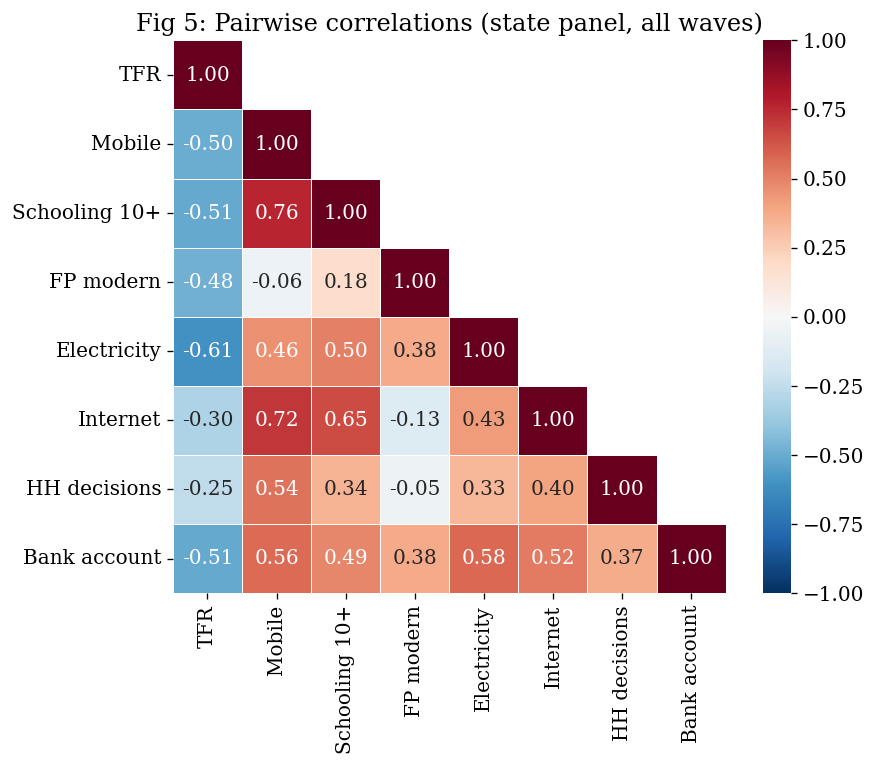

In [9]:
# --- Fig 5: Correlation heatmap of analysis variables ---

heat_vars = ["tfr", "mobile", "schooling", "fp_modern", "electricity", "internet", "empowerment", "bank"]
heat_labels = [
    "TFR", "Mobile", "Schooling 10+", "FP modern", "Electricity",
    "Internet", "HH decisions", "Bank account",
]
corr = panel_main[heat_vars].corr()
corr.index = corr.columns = heat_labels

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Fig 5: Pairwise correlations (state panel, all waves)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig5_correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [10]:
# --- Econometric helpers ---

def run_pooled_ols(data, treatment="mobile", controls=None, wave_fe=True):
    controls = controls or REG_CONTROLS
    rhs = " + ".join([treatment] + controls)
    if wave_fe:
        rhs += " + C(round)"
    formula = f"tfr ~ {rhs}"
    model = smf.ols(formula, data=data).fit(
        cov_type="cluster", cov_kwds={"groups": data["state"]}
    )
    return model


def run_state_fe(data, treatment="mobile", controls=None):
    controls = controls or REG_CONTROLS
    p = data.set_index(["state", "wave"]).sort_index()
    y = p["tfr"]
    X = p[[treatment] + controls]
    model = PanelOLS(y, X, entity_effects=True, time_effects=True).fit(
        cov_type="clustered", cluster_entity=True
    )
    return model


def coef_table(*models, names=None):
    names = names or [f"Model {i+1}" for i in range(len(models))]
    rows = []
    for name, m in zip(names, models):
        is_panel = hasattr(m, "rsquared_within")  # linearmodels PanelOLS
        for var in m.params.index:
            if not is_panel and (var == "Intercept" or str(var).startswith("C(")):
                continue
            se = m.std_errors[var] if is_panel else m.bse[var]
            rows.append({
                "Model": name, "Variable": var,
                "Coef": m.params[var], "SE": se, "p": m.pvalues[var],
            })
    return pd.DataFrame(rows)


def print_model_summary(label, model, treatment="mobile"):
    print("=" * 70)
    print(label)
    print("=" * 70)
    if hasattr(model, "rsquared_within"):
        print(f"R² (within) = {model.rsquared_within:.3f}  |  N = {model.nobs}  |  Clusters = state")
    else:
        print(f"R² = {model.rsquared:.3f}  |  N = {int(model.nobs)}  |  Clusters = state")
    if treatment in model.params.index:
        b = model.params[treatment]
        p = model.pvalues[treatment]
        print(f"\n{treatment}: coef = {b:.5f}, p = {p:.4f}")
        print(f"  → A 10 pp increase in {treatment} is associated with ΔTFR = {b * 10:.3f} children/woman")
    print()

In [11]:
# --- Model 1: Pooled OLS with wave fixed effects ---

ols_mobile = run_pooled_ols(panel_reg, treatment="mobile")
print_model_summary("Model 1 — Pooled OLS (wave FE, state-clustered SEs)", ols_mobile)
print(ols_mobile.summary().tables[1])

Model 1 — Pooled OLS (wave FE, state-clustered SEs)
R² = 0.578  |  N = 107  |  Clusters = state

mobile: coef = -0.01222, p = 0.0080
  → A 10 pp increase in mobile is associated with ΔTFR = -0.122 children/woman

                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              5.1982      0.414     12.543      0.000       4.386       6.010
C(round)[T.NFHS-5]     0.0766      0.071      1.082      0.279      -0.062       0.215
C(round)[T.NFHS-6]     0.1814      0.075      2.429      0.015       0.035       0.328
mobile                -0.0122      0.005     -2.652      0.008      -0.021      -0.003
schooling              0.0005      0.005      0.102      0.918      -0.009       0.010
fp_modern             -0.0135      0.003     -4.255      0.000      -0.020      -0.007
electricity           -0.0204      0.005     -4.273      0.000      -0.030      -0.011


In [12]:
# --- Model 2: State + wave two-way fixed effects ---

fe_mobile = run_state_fe(panel_reg, treatment="mobile")
print_model_summary("Model 2 — State FE + Wave FE (clustered by state)", fe_mobile)
print(fe_mobile.summary.tables[1])

Model 2 — State FE + Wave FE (clustered by state)
R² (within) = 0.501  |  N = 107  |  Clusters = state

mobile: coef = -0.00860, p = 0.3138
  → A 10 pp increase in mobile is associated with ΔTFR = -0.086 children/woman

                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
mobile         -0.0086     0.0085    -1.0154     0.3138     -0.0255      0.0083
schooling      -0.0032     0.0165    -0.1939     0.8469     -0.0361      0.0297
fp_modern      -0.0090     0.0037    -2.4293     0.0180     -0.0164     -0.0016
electricity    -0.0102     0.0047    -2.1832     0.0328     -0.0195     -0.0009


In [13]:
# --- Model 3: Robustness ---

# 3a. Internet instead of mobile (NFHS-5/6)
_, panel_internet = build_panel(
    df_nfhs, INTERNET_ROUNDS, require_vars=["tfr", "internet"]
)
panel_internet_reg = panel_internet.dropna(subset=["tfr", "internet"] + REG_CONTROLS)
ols_internet = run_pooled_ols(panel_internet_reg, treatment="internet")
fe_internet = run_state_fe(panel_internet_reg, treatment="internet")
print_model_summary("Robustness 3a — OLS with internet (NFHS-5/6)", ols_internet, treatment="internet")
print_model_summary("Robustness 3a — State FE with internet (NFHS-5/6)", fe_internet, treatment="internet")

# 3b. First-difference (NFHS-4 → NFHS-6)
fd = delta.dropna(subset=["d_tfr", "d_mobile"]).reset_index()
fd_ols = smf.ols("d_tfr ~ d_mobile", data=fd).fit(
    cov_type="cluster", cov_kwds={"groups": fd["state"]}
)
print("\nRobustness 3b — First-difference OLS (NFHS-4→6):")
print(f"  d_mobile coef = {fd_ols.params['d_mobile']:.5f}, p = {fd_ols.pvalues['d_mobile']:.4f}")

# 3c. Leave-one-out sensitivity for mobile FE coefficient
print("\nRobustness 3c — Leave-one-out (state FE, mobile coef):")
loo = []
for st in panel_reg["state"].unique():
    sub = panel_reg[panel_reg["state"] != st]
    try:
        m = run_state_fe(sub)
        loo.append({"dropped_state": st, "mobile_coef": m.params["mobile"], "p": m.pvalues["mobile"]})
    except Exception:
        pass
loo_df = pd.DataFrame(loo)
print(loo_df.describe()[["mobile_coef"]].T)
print(f"  Range: [{loo_df['mobile_coef'].min():.5f}, {loo_df['mobile_coef'].max():.5f}]")

# 3d. Urban / Rural subsamples
for area in ["Urban", "Rural"]:
    _, p_area = build_panel(df_nfhs, MAIN_ROUNDS, area=area, require_vars=["tfr", "mobile"])
    p_area = p_area.dropna(subset=["tfr", "mobile"] + REG_CONTROLS)
    if len(p_area) < 20:
        continue
    m = run_pooled_ols(p_area)
    print(f"\nRobustness 3d — Pooled OLS ({area}, N={len(p_area)}): mobile coef = {m.params['mobile']:.5f}, p = {m.pvalues['mobile']:.4f}")

# Comparison table
comp = coef_table(ols_mobile, fe_mobile, ols_internet, fe_internet,
                  names=["OLS mobile", "FE mobile", "OLS internet", "FE internet"])
comp = comp[comp["Variable"].isin(["mobile", "internet"])]
print("\n" + "=" * 70)
print("KEY COEFFICIENTS — MAIN vs ROBUSTNESS")
print("=" * 70)
print(comp.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
comp.to_csv(OUTPUT_DIR / "regression_comparison.csv", index=False)

Robustness 3a — OLS with internet (NFHS-5/6)
R² = 0.389  |  N = 71  |  Clusters = state

internet: coef = -0.00882, p = 0.0451
  → A 10 pp increase in internet is associated with ΔTFR = -0.088 children/woman

Robustness 3a — State FE with internet (NFHS-5/6)
R² (within) = -0.051  |  N = 71  |  Clusters = state

internet: coef = -0.00333, p = 0.5103
  → A 10 pp increase in internet is associated with ΔTFR = -0.033 children/woman


Robustness 3b — First-difference OLS (NFHS-4→6):
  d_mobile coef = -0.01706, p = 0.0326

Robustness 3c — Leave-one-out (state FE, mobile coef):
             count      mean       std       min       25%       50%  \
mobile_coef   38.0 -0.008569  0.001235 -0.010745 -0.009158 -0.008587   

                  75%       max  
mobile_coef -0.008345 -0.004569  
  Range: [-0.01074, -0.00457]

Robustness 3d — Pooled OLS (Urban, N=106): mobile coef = -0.01678, p = 0.0016

Robustness 3d — Pooled OLS (Rural, N=101): mobile coef = -0.01055, p = 0.0151

KEY COEFFICIENTS — M